In [36]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import imgaug as ia
import imgaug.augmenters as iaa
import pickle
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC

ia.seed(1)

In [13]:
seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Crop(percent=(0, 0.1)), # random crops
    # Small gaussian blur with random sigma between 0 and 0.5.
    # But we only blur about 50% of all images.
    iaa.Sometimes(
        0.5,
        iaa.GaussianBlur(sigma=(0, 0.5))
    ),
    # Strengthen or weaken the contrast in each image.
    iaa.LinearContrast((0.75, 1.5)),
    # Add gaussian noise.
    # For 50% of all images, we sample the noise once per pixel.
    # For the other 50% of all images, we sample the noise per pixel AND
    # channel. This can change the color (not only brightness) of the
    # pixels.
    iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05*255), per_channel=0.5),
    # Make some images brighter and some darker.
    # In 20% of all cases, we sample the multiplier once per channel,
    # which can end up changing the color of the images.
    iaa.Multiply((0.8, 1.2), per_channel=0.2),
    # Apply affine transformations to each image.
    # Scale/zoom them, translate/move them, rotate them and shear them.
    iaa.Affine(
        scale={"x": (0.8, 1.2), "y": (0.8, 1.2)},
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-10, 10),
        shear=(-4, 4)
    )
], random_order=True) # apply augmenters in random order

In [14]:
path ="samples"
typ = 'train/'

imgs = os.listdir(path)
labels = [f.strip('.jpg') for f in imgs]

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')

In [141]:
N = 1000
dim = 227

if not os.path.isdir(f'{typ}'):
        os.mkdir(f'{typ}')
        
for label in labels:
    img = cv2.imread(os.path.join(path,f'{label}.jpg'),0)
    # resize image
    img = cv2.resize(img,(dim,dim), interpolation = cv2.INTER_AREA)
    images = np.array([ img for _ in range(N)],dtype=np.uint8)
    
    images_aug = seq(images=images)

    if not os.path.isdir(f'train/{label}'):
        os.mkdir(f'train/{label}')

    for i in range(N):
        cv2.imwrite(f'train/{label}/{label}_{i}.jpg',images_aug[i])

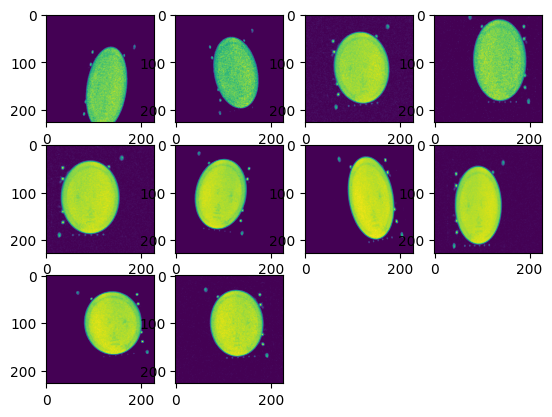

In [142]:
num = 10
col=4
imgs = list(np.random.choice(len(images_aug),num))
for i in range(num):
    plt.subplot(num/col if num%col==0 else int(num/col)+1,col,i+1)
    plt.imshow(images_aug[imgs[i]])

In [69]:
dic = {}
for k,l in enumerate(labels):
    dic[k]=l
dic

{0: '24. Google Nest Hub Max_H2A',
 1: '25. Google Stadia Game Controller_H2B',
 2: '09. Google Nest Cam IQ Outdoor_KT1UM9',
 3: '08. Google Chromecast Black_NC2-6A5 BLACK',
 4: '26. Google Door Camera_ATLRQ1US',
 5: '12. Google TV Remote_G9N9N',
 6: '19. Google Nest Doorbell (Battery)_GWX3T',
 7: '03. Chromecast Ultra (2016)_G2RNL',
 8: '27. Google Nest Learning Thermostat (White)_AK2L2R',
 9: '10. Google Nest Wifi Router_G6ZUC',
 10: '15. Google Home_Home',
 11: '18. Google Nest Wifi Pro_SNOW',
 12: '02. Google Nest Hello Doorbell_A0077',
 13: '05. Google Nest Cam Outdoor_G3AL9',
 14: '21. Google Nest Power Connector_GVNZ4',
 15: 'Google Nest Audio',
 16: '14. Google Nest Protect smoke alarm_NST-4895',
 17: '22. Google Nest Temperature Sensor White_T5000SF',
 18: '06. Google Nest Cam IQ Indoor_G9Q9T',
 19: '01. Google Nest Learning Thermostat (Black)_H1HB1J',
 20: '04. Google Wifi (1 pk)_H2D',
 21: '20. Google Nest Wifi Point_H2E-Google',
 22: '11. Google Home Mini_H2C',
 23: '17. Go

In [145]:
X = []
y = [] #number
path="train"
IMG_SIZE=100
for k,label in enumerate(labels):
    for i in os.listdir(os.path.join(path,label)):
        img = cv2.imread(os.path.join(path,label,i),0)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        X.append(img)
        y.append(k)

In [146]:
# shuffle
X,y = shuffle(X,y)

In [147]:
X = np.array(X).reshape(len(X),-1)
# norm
X = X/255.0
y = np.array(y)

In [148]:
print(X.shape)
print(y.shape)

(26000, 10000)
(26000,)


In [149]:
# split
X_train, X_val, y_train, y_val = train_test_split(X,y)

In [ ]:
svc = SVC(kernel='linear',gamma='auto')
svc.fit(X_train, y_train)

In [ ]:
y2 = svc.predict(X_val)

In [ ]:
# calc accuracy
print("Accuracy on unknown data is",accuracy_score(y_val,y2))

In [ ]:
print("Accuracy on unknown data is")
print(classification_report(y_val,y2))

In [94]:
# save the model to disk
filename = 'object_classifier.sav'
pickle.dump(svc, open(filename, 'wb'))

Even when flatten length of new income data does not equal, model still work

Text(0.5, 1.0, 'pred: 20. Google Nest Wifi Point_H2E-Google\n(20. Google Nest Wifi Point_H2E-Google)')

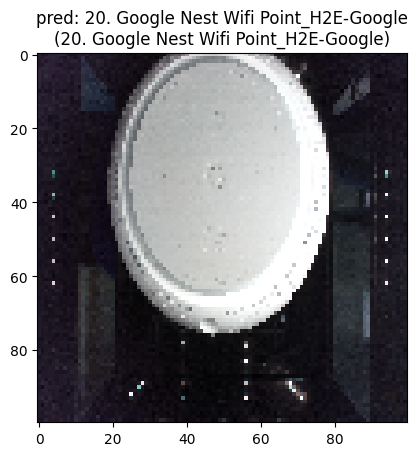

In [134]:
# random test
path = 'samples'
imgs = os.listdir(path)
i = random.choice(imgs)
img = cv2.imread(os.path.join(path,i))
img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
plt.imshow(img)
img = img/255.0
img = img.reshape(1,-1)
y= svc.predict(img)
plt.title("pred: " + i.strip('.jpg') +"\n(" + dic[int(y)] + ")")

In [140]:
path = "samples"
for i in imgs:
    img = cv2.imread(os.path.join(path,i))
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0
    img = img.reshape(1,-1)
    y= svc.predict(img)
    pred = dic[int(y)]
    print(i,"pred: ",i.strip('.jpg') == pred)

24. Google Nest Hub Max_H2A.jpg pred:  True
25. Google Stadia Game Controller_H2B.jpg pred:  True
09. Google Nest Cam IQ Outdoor_KT1UM9.jpg pred:  True
08. Google Chromecast Black_NC2-6A5 BLACK.jpg pred:  True
26. Google Door Camera_ATLRQ1US.jpg pred:  True
12. Google TV Remote_G9N9N.jpg pred:  True
19. Google Nest Doorbell (Battery)_GWX3T.jpg pred:  True
03. Chromecast Ultra (2016)_G2RNL.jpg pred:  True
27. Google Nest Learning Thermostat (White)_AK2L2R.jpg pred:  True
10. Google Nest Wifi Router_G6ZUC.jpg pred:  True
15. Google Home_Home.jpg pred:  True
18. Google Nest Wifi Pro_SNOW.jpg pred:  True
02. Google Nest Hello Doorbell_A0077.jpg pred:  True
05. Google Nest Cam Outdoor_G3AL9.jpg pred:  True
21. Google Nest Power Connector_GVNZ4.jpg pred:  True
Google Nest Audio.jpg pred:  True
14. Google Nest Protect smoke alarm_NST-4895.jpg pred:  True
22. Google Nest Temperature Sensor White_T5000SF.jpg pred:  True
06. Google Nest Cam IQ Indoor_G9Q9T.jpg pred:  True
01. Google Nest Learnin